# Forecasting with Machine Learning: The Core Ideas

### AI-powered Investment and Risk Management — Lecture 2b

---

There is no deep learning in this notebook. No TensorFlow, no epochs, no GPU. Everything
here runs in **under a minute on any laptop**, and every model is one line of scikit-learn.

That is deliberate. Almost everything that goes wrong in applied forecasting goes wrong
*before* the choice of model, and you can see all of it with a straight line and a small tree.

## Learning objectives

By the end you should be able to:

- **Explain** how a time series becomes a supervised learning problem, and why that step is the one that matters
- **Compare** any forecast against a trivial benchmark, and say what "good" means
- **Recognise** overfitting from the shape of two error curves rather than from a single number
- **Distinguish** error the model caused from error the data guaranteed
- **Explain** why shuffling a time series before splitting it produces a score that is not real

## How to use it

Run the cells in order. Charts with a **play button** or a **slider** are meant to be moved —
the slider is the lesson, not decoration. Part 9 hands you the controls.

---

*This is the on-ramp for Lecture 2c, where the same ideas are pushed through LSTMs, GRUs,
convolutional networks and reservoirs.*

## Part 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

COL = ["#123F69", "#E4572E", "#17A398", "#F3A712", "#7B2D8E", "#B33951"]
pio.templates["airm"] = go.layout.Template(layout=dict(
    colorway=COL, font=dict(family="Helvetica, Arial, sans-serif", size=13, color="#22303C"),
    paper_bgcolor="white", plot_bgcolor="#F7F9FB",
    xaxis=dict(gridcolor="#E2EBF4"), yaxis=dict(gridcolor="#E2EBF4"),
    legend=dict(bgcolor="rgba(255,255,255,0.75)", bordercolor="#E2EBF4", borderwidth=1),
    margin=dict(l=60, r=30, t=80, b=55)))
pio.templates.default = "airm"
print("Ready. Nothing to download, nothing to install.")

Ready. Nothing to download, nothing to install.


## Part 1 — A series is made of parts

Our example is daily electricity demand for a small town: 300 days of it. We are going to
pretend we do not know how it was made, and try to forecast tomorrow from the past.

But since *we* built it, we can look inside. It is exactly three things added together:

$$\text{demand}_t = \underbrace{\text{slow trend}}_{\text{predictable}} + \underbrace{\text{weekly cycle}}_{\text{predictable}} + \underbrace{\text{random noise}}_{\text{never predictable}}$$

Hold on to that third term. **No model, however sophisticated, can forecast the noise.**
It is the part of tomorrow that has not been decided yet. Almost every disappointment in
applied forecasting is somebody expecting a model to predict it anyway.

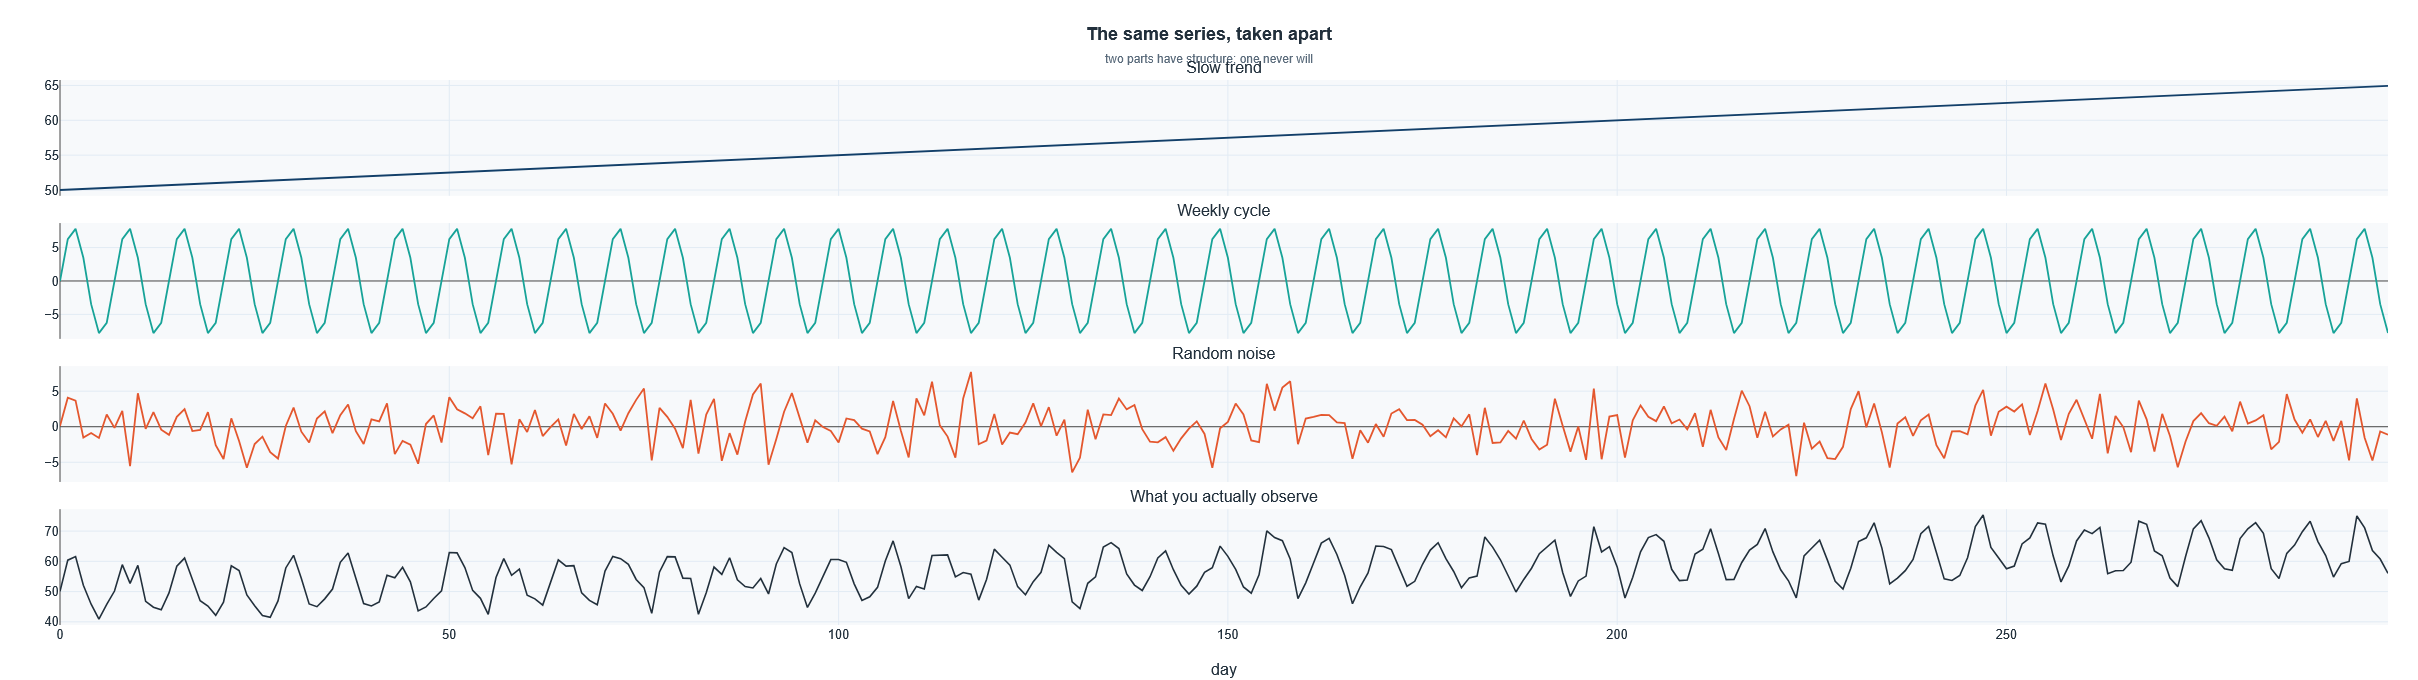

Variance of the predictable part :   50.21
Variance of the noise            :    7.54   <- nobody gets this


In [2]:
SEED = 11
rng = np.random.default_rng(SEED)
n = 300
t = np.arange(n)

trend  = 50 + 0.05 * t                       # slow growth
weekly = 8 * np.sin(2 * np.pi * t / 7)       # the working week
noise  = rng.normal(0, 3, n)                 # genuinely unpredictable
demand = trend + weekly + noise
signal = trend + weekly                      # the part that COULD be forecast

fig = make_subplots(rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                    subplot_titles=("Slow trend", "Weekly cycle", "Random noise",
                                    "What you actually observe"))
for r, (y, c, nm) in enumerate([(trend, COL[0], "trend"), (weekly, COL[2], "weekly"),
                                (noise, COL[1], "noise")], start=1):
    fig.add_trace(go.Scatter(y=y, mode="lines", line=dict(color=c, width=1.8), name=nm), row=r, col=1)
fig.add_trace(go.Scatter(y=demand, mode="lines", line=dict(color="#22303C", width=1.6),
                         name="demand"), row=4, col=1)
fig.update_layout(height=680, showlegend=False,
                  title="<b>The same series, taken apart</b><br><span style='font-size:12px;"
                        "color:#5A6B7B'>two parts have structure; one never will</span>")
fig.update_xaxes(title_text="day", row=4, col=1)
fig.show()

print(f"Variance of the predictable part : {signal.var():7.2f}")
print(f"Variance of the noise            : {noise.var():7.2f}   <- nobody gets this")

## Part 2 — The one idea that makes ML forecasting work

Machine learning models do not understand time. They understand **tables**: a row of inputs,
a value to predict. So the entire trick is turning a series into a table.

We slide a window along the series. Everything inside the window is the input; the very next
value is the answer. Slide one step, get another row. Do it 293 times and you have a dataset.

**Press play below.** Watch the window march forward and the table fill up underneath.

That is it. That is the whole conceptual leap. Everything after this — linear models, trees,
LSTMs — is just a different way of learning the mapping from *the row* to *the answer*.

300 observations  ->  293 rows of 7 inputs, each with 1 answer



,day t-7,day t-6,day t-5,day t-4,day t-3,day t-2,day t-1,ANSWER: day t
0,50.1,60.4,61.6,52.1,45.8,40.9,45.8,50.2
1,60.4,61.6,52.1,45.8,40.9,45.8,50.2,58.9
2,61.6,52.1,45.8,40.9,45.8,50.2,58.9,52.7
3,52.1,45.8,40.9,45.8,50.2,58.9,52.7,58.7
4,45.8,40.9,45.8,50.2,58.9,52.7,58.7,46.8


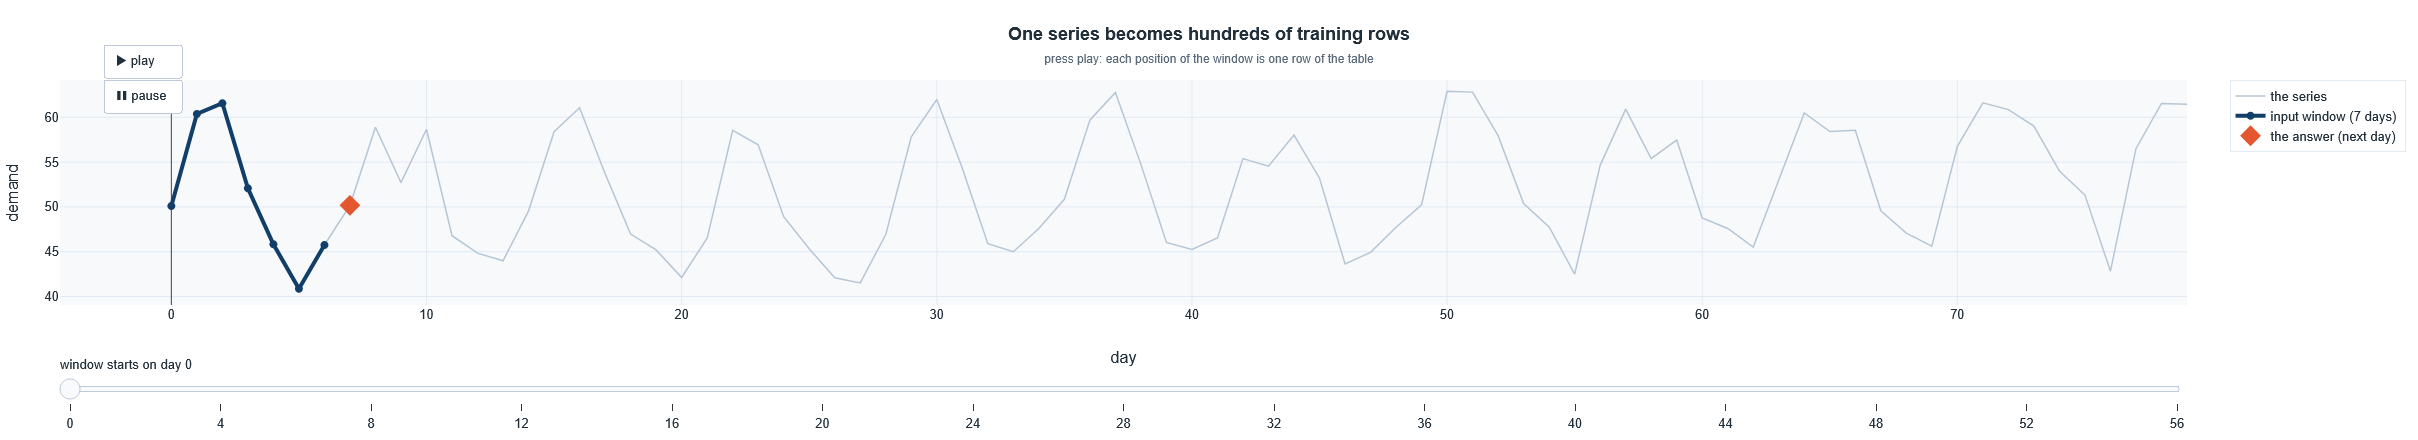

In [3]:
W = 7   # one week of history as the input

def make_table(series, window=W, horizon=1):
    """Slide a window along the series. Returns inputs X, answers y."""
    X = np.lib.stride_tricks.sliding_window_view(series, window)[:-horizon]
    y = series[window + horizon - 1:]
    return X, y

X, y = make_table(demand)
print(f"{len(demand)} observations  ->  {X.shape[0]} rows of {X.shape[1]} inputs, "
      f"each with 1 answer\n")
display(pd.DataFrame(X[:5], columns=[f"day t-{W-i}" for i in range(W)])
          .assign(**{"ANSWER: day t": y[:5]}).round(1))

# ---- animation: the window sliding along ----------------------------------
frames, step = [], 4
positions = list(range(0, 60, step))
for p in positions:
    frames.append(go.Frame(name=str(p), data=[
        go.Scatter(x=list(range(p, p + W)), y=demand[p:p + W], mode="lines+markers",
                   line=dict(color=COL[0], width=4), marker=dict(size=8)),
        go.Scatter(x=[p + W], y=[demand[p + W]], mode="markers",
                   marker=dict(color=COL[1], size=16, symbol="diamond"))], traces=[1, 2]))

fig = go.Figure(
    data=[go.Scatter(y=demand[:80], mode="lines", line=dict(color="#B7C6D4", width=1.5),
                     name="the series"),
          go.Scatter(x=list(range(0, W)), y=demand[0:W], mode="lines+markers",
                     line=dict(color=COL[0], width=4), marker=dict(size=8),
                     name="input window (7 days)"),
          go.Scatter(x=[W], y=[demand[W]], mode="markers",
                     marker=dict(color=COL[1], size=16, symbol="diamond"),
                     name="the answer (next day)")],
    frames=frames)
fig.update_layout(
    title="<b>One series becomes hundreds of training rows</b><br><span style='font-size:12px;"
          "color:#5A6B7B'>press play: each position of the window is one row of the table</span>",
    xaxis_title="day", yaxis_title="demand", height=440,
    updatemenus=[dict(type="buttons", showactive=False, x=0.02, y=1.16, xanchor="left",
        buttons=[dict(label="▶ play", method="animate",
                      args=[None, dict(frame=dict(duration=260, redraw=True),
                                       fromcurrent=True, transition=dict(duration=0))]),
                 dict(label="❚❚ pause", method="animate",
                      args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")])])],
    sliders=[dict(active=0, y=-0.12, currentvalue=dict(prefix="window starts on day "),
                  steps=[dict(label=str(p), method="animate",
                              args=[[str(p)], dict(mode="immediate",
                                                   frame=dict(duration=0, redraw=True))])
                         for p in positions])])
fig.show()

## Part 3 — Before any model: what does "good" mean?

Suppose your model predicts tomorrow's demand with an average error of 3.1 units. Is that good?

**You cannot answer that.** Not without something to compare it against.

So we start with the laziest forecast imaginable — *tomorrow will be the same as today* — and
make every model beat it. This is the **naive benchmark**, and it is unreasonably hard to beat
on real data.

We also split the data by time: the first 80% to learn from, the last 20% to be judged on.
Never at random. Part 7 shows what happens when you forget this.

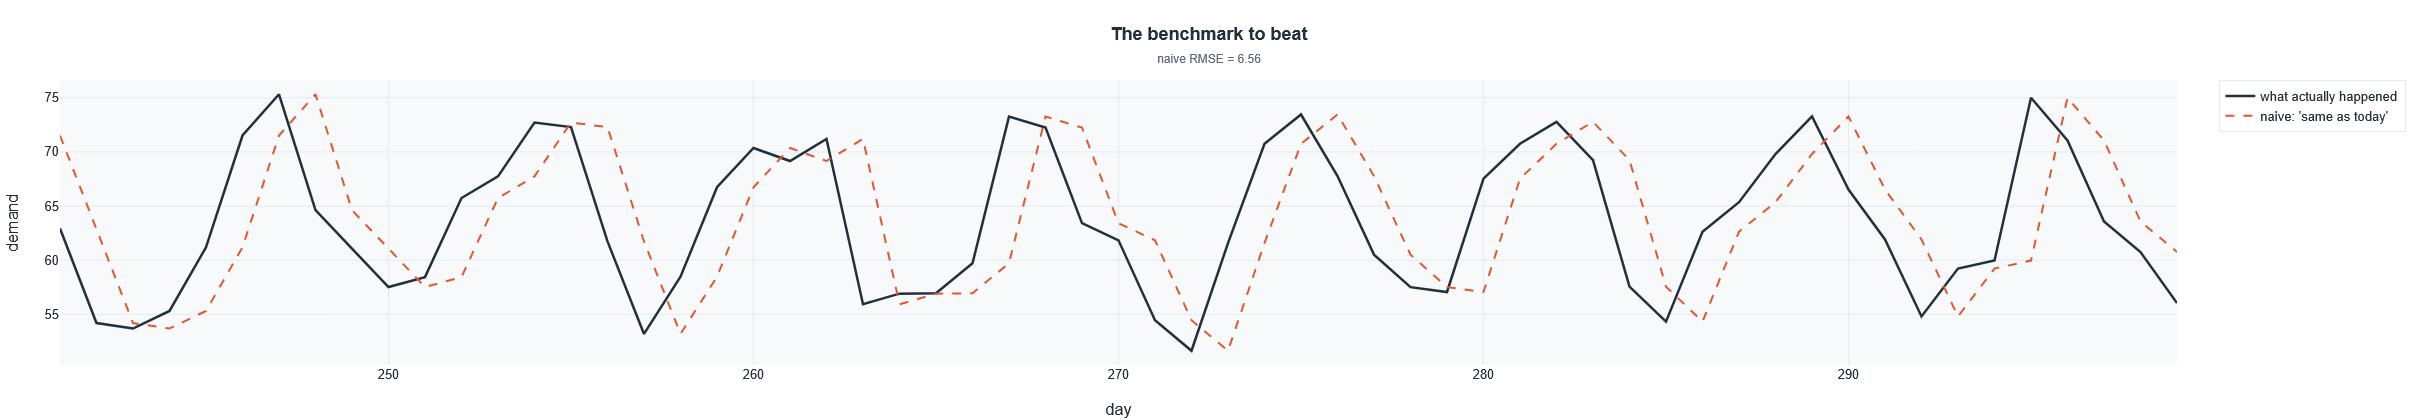

Naive benchmark RMSE     6.56   <- beat this or go home
Best possible RMSE       2.67   <- pure noise; nobody beats this


In [4]:
cut = int(0.8 * len(y))
Xtr, Xte, ytr, yte = X[:cut], X[cut:], y[:cut], y[cut:]
days_te = np.arange(W, len(demand))[cut:]

def rmse(a, b): return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

naive_pred = Xte[:, -1]                      # "tomorrow = today"
naive_rmse = rmse(naive_pred, yte)

# the best that ANY method could do: predict the noise-free signal
best_possible = rmse(signal[W:][cut:], yte)

fig = go.Figure()
fig.add_trace(go.Scatter(x=days_te, y=yte, mode="lines", name="what actually happened",
                         line=dict(color="#22303C", width=2.5)))
fig.add_trace(go.Scatter(x=days_te, y=naive_pred, mode="lines", name="naive: 'same as today'",
                         line=dict(color=COL[1], width=2, dash="dash")))
fig.update_layout(title=f"<b>The benchmark to beat</b><br><span style='font-size:12px;"
                        f"color:#5A6B7B'>naive RMSE = {naive_rmse:.2f}</span>",
                  xaxis_title="day", yaxis_title="demand", height=420)
fig.show()

print(f"Naive benchmark RMSE   {naive_rmse:6.2f}   <- beat this or go home")
print(f"Best possible RMSE     {best_possible:6.2f}   <- pure noise; nobody beats this")

## Part 4 — Your first forecasting model

One line of scikit-learn. It learns a weight for each of the seven days in the window and
adds them up — a weighted average of last week, with the weights chosen by least squares.

It is about as simple as a model can be while still being a model. Watch what it does to the
benchmark.

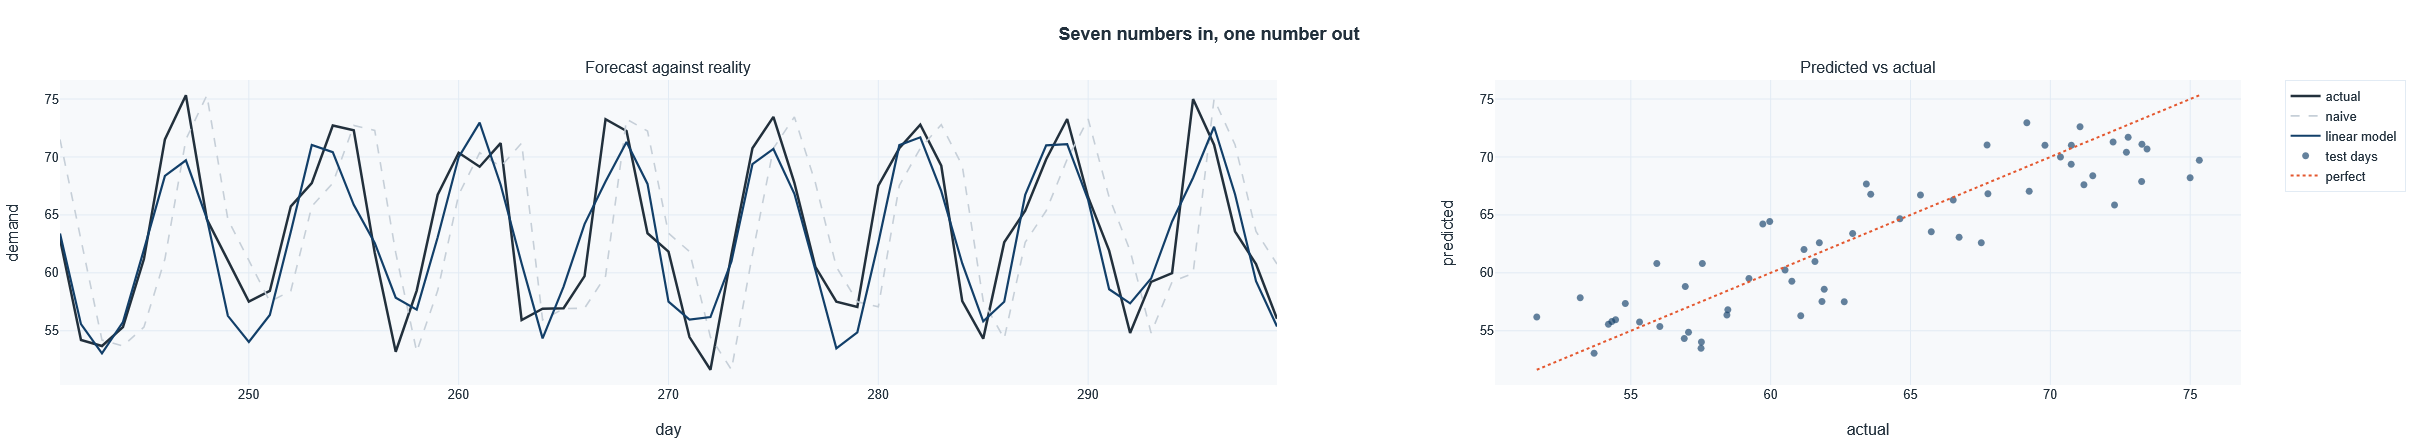

naive RMSE              6.56
linear model RMSE       3.09
best possible RMSE      2.67

Improvement on naive   52.9%
Of the improvement that was AVAILABLE, it captured  89.0%


In [5]:
model = LinearRegression().fit(Xtr, ytr)
pred = model.predict(Xte)
lin_rmse = rmse(pred, yte)

fig = make_subplots(rows=1, cols=2, column_widths=[0.62, 0.38],
                    subplot_titles=("Forecast against reality", "Predicted vs actual"))
fig.add_trace(go.Scatter(x=days_te, y=yte, mode="lines", name="actual",
                         line=dict(color="#22303C", width=2.5)), row=1, col=1)
fig.add_trace(go.Scatter(x=days_te, y=naive_pred, mode="lines", name="naive",
                         line=dict(color="#C6CFD8", width=1.6, dash="dash")), row=1, col=1)
fig.add_trace(go.Scatter(x=days_te, y=pred, mode="lines", name="linear model",
                         line=dict(color=COL[0], width=2.2)), row=1, col=1)
fig.add_trace(go.Scatter(x=yte, y=pred, mode="markers", name="test days",
                         marker=dict(color=COL[0], size=7, opacity=0.65)), row=1, col=2)
lo, hi = float(min(yte.min(), pred.min())), float(max(yte.max(), pred.max()))
fig.add_trace(go.Scatter(x=[lo, hi], y=[lo, hi], mode="lines", name="perfect",
                         line=dict(color=COL[1], width=2, dash="dot")), row=1, col=2)
fig.update_xaxes(title_text="day", row=1, col=1); fig.update_xaxes(title_text="actual", row=1, col=2)
fig.update_yaxes(title_text="demand", row=1, col=1); fig.update_yaxes(title_text="predicted", row=1, col=2)
fig.update_layout(height=440, title="<b>Seven numbers in, one number out</b>")
fig.show()

skill = 1 - lin_rmse / naive_rmse
print(f"naive RMSE            {naive_rmse:6.2f}")
print(f"linear model RMSE     {lin_rmse:6.2f}")
print(f"best possible RMSE    {best_possible:6.2f}")
print(f"\nImprovement on naive  {100*skill:5.1f}%")
print(f"Of the improvement that was AVAILABLE, it captured "
      f"{100*(naive_rmse-lin_rmse)/(naive_rmse-best_possible):5.1f}%")

### What did it actually learn?

The model has seven weights, one per day of the window. Plot them and the weekly cycle appears
on its own — the model was never told that a week is seven days long.

This is worth pausing on. Nobody engineered a "day of week" feature. The structure was in the
data, and least squares found it.

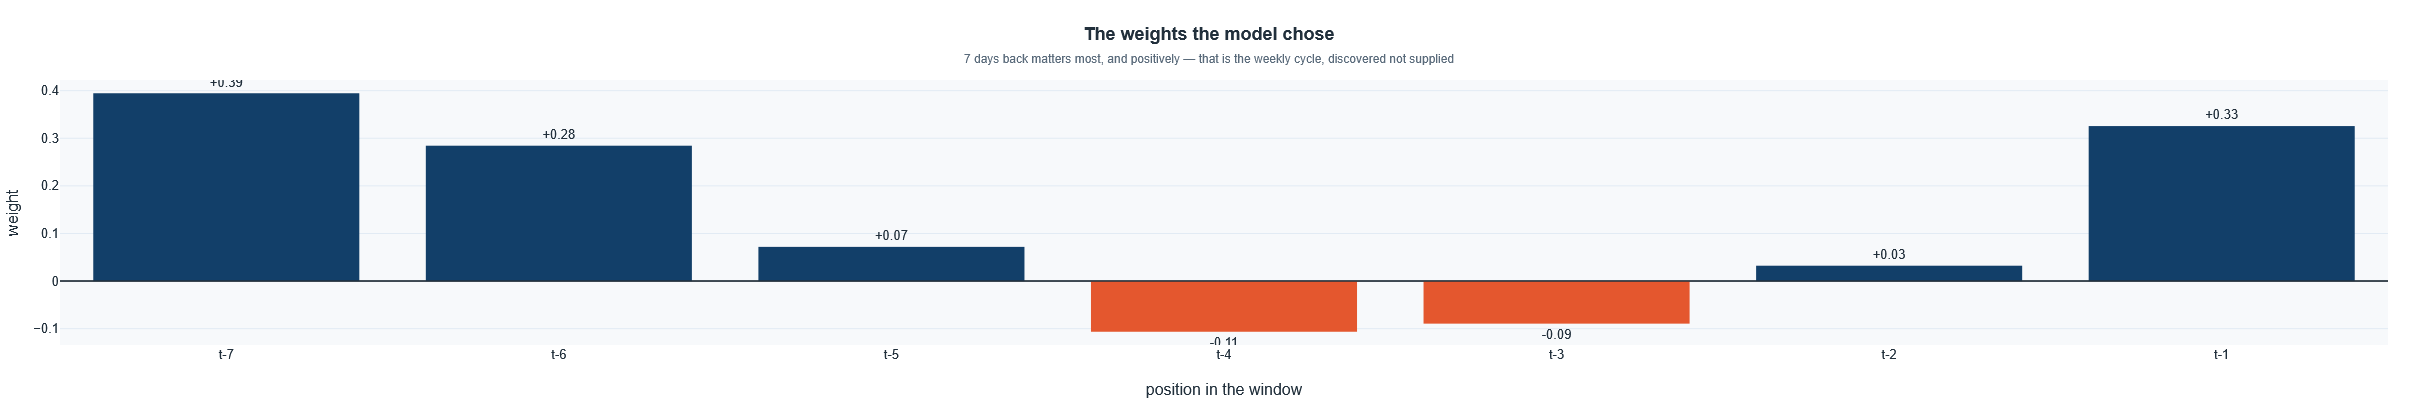

In [6]:
fig = go.Figure(go.Bar(x=[f"t-{W-i}" for i in range(W)], y=model.coef_,
                       marker_color=[COL[0] if c > 0 else COL[1] for c in model.coef_],
                       text=[f"{c:+.2f}" for c in model.coef_], textposition="outside"))
fig.add_hline(y=0, line_color="#22303C", line_width=1.5)
fig.update_layout(title="<b>The weights the model chose</b><br><span style='font-size:12px;"
                        "color:#5A6B7B'>7 days back matters most, and positively — that is the "
                        "weekly cycle, discovered not supplied</span>",
                  xaxis_title="position in the window", yaxis_title="weight", height=400)
fig.show()

## Part 5 — More complexity is not more accuracy

Now the central idea in machine learning, and the one students most often need to *see*
before they believe it.

We swap the linear model for a decision tree and turn up its depth. A deeper tree carves the
data into finer and finer boxes, so it fits the days it trained on better and better. Given
enough depth it gets them perfect.

To make the effect visible we first give the model a realistic handicap: **only 30 days of
history to learn from**. Small, noisy training sets are the normal condition in finance, not
the exception.

**Move the slider and watch the two curves on the right.**

The training error falls the whole way down. The test error falls, bottoms out around depth 4,
and then climbs. Past that point the tree has stopped learning the weekly cycle and started
memorising which particular random wobbles happened on which particular training days. Those
wobbles never repeat, so the memorisation is worse than useless.

This is **overfitting**, and note how invisible it is from the training curve alone. One number
going down is not evidence of anything.

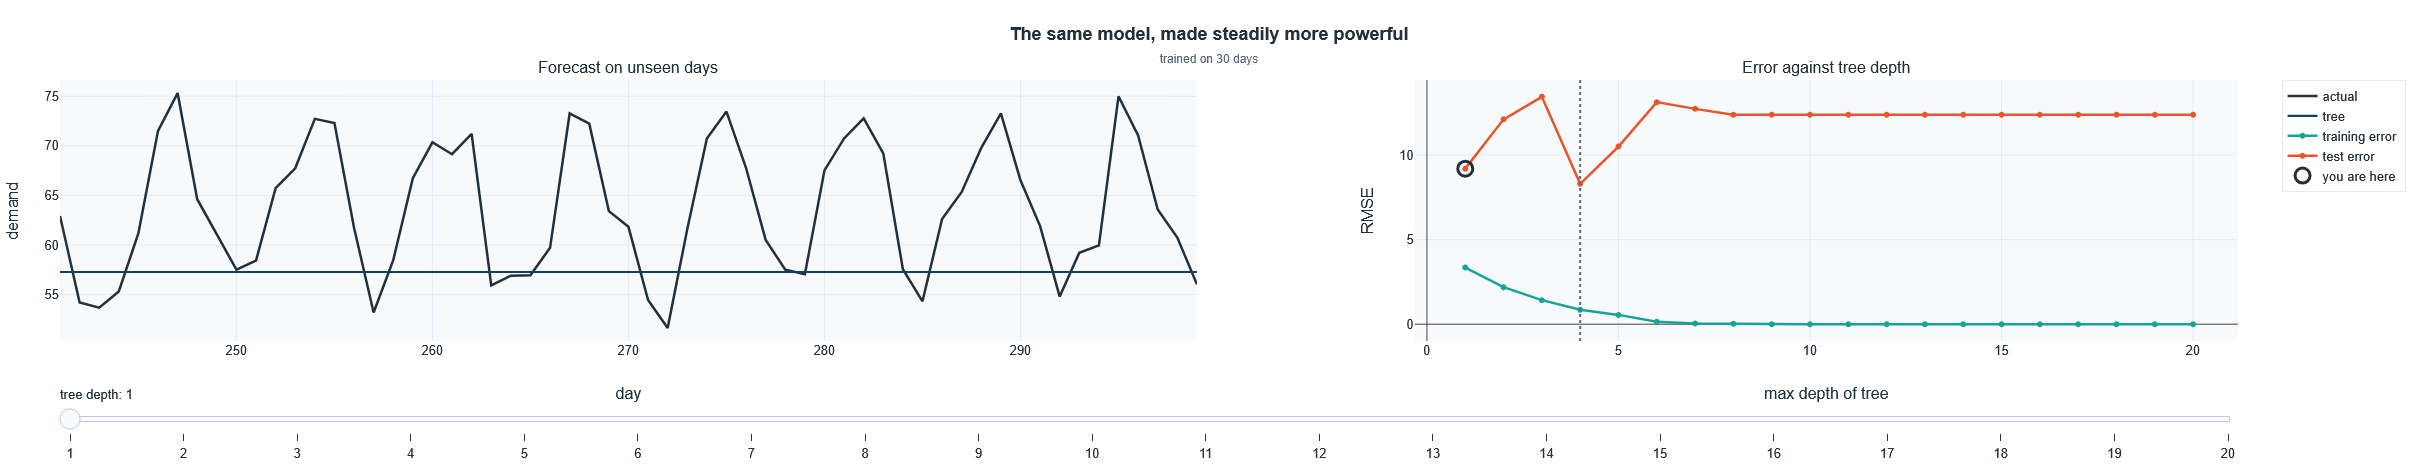

Best depth on unseen days : 4   (test RMSE 8.30)
Deepest tree (depth 20)   : training RMSE 0.00, test RMSE 12.38

Going from the best depth to the deepest tree makes the training error look 0.86 better,
and the actual forecasts 1.49x worse.


In [7]:
N_SMALL = 30          # a realistic handicap: one month of history
depths = list(range(1, 21))

def depth_curves(n_train):
    tr, te, pr = [], [], {}
    for dpt in depths:
        tree = DecisionTreeRegressor(max_depth=dpt, random_state=0).fit(Xtr[:n_train], ytr[:n_train])
        p = tree.predict(Xte)
        pr[dpt] = p
        tr.append(rmse(tree.predict(Xtr[:n_train]), ytr[:n_train]))
        te.append(rmse(p, yte))
    return tr, te, pr

tr_err, te_err, preds_by_depth = depth_curves(N_SMALL)
best_depth = depths[int(np.argmin(te_err))]

fig = make_subplots(rows=1, cols=2, column_widths=[0.58, 0.42],
                    subplot_titles=("Forecast on unseen days", "Error against tree depth"))
fig.add_trace(go.Scatter(x=days_te, y=yte, mode="lines", name="actual",
                         line=dict(color="#22303C", width=2.5)), row=1, col=1)
fig.add_trace(go.Scatter(x=days_te, y=preds_by_depth[1], mode="lines", name="tree",
                         line=dict(color=COL[0], width=2.2)), row=1, col=1)
fig.add_trace(go.Scatter(x=depths, y=tr_err, mode="lines+markers", name="training error",
                         line=dict(color=COL[2], width=2.5)), row=1, col=2)
fig.add_trace(go.Scatter(x=depths, y=te_err, mode="lines+markers", name="test error",
                         line=dict(color=COL[1], width=2.5)), row=1, col=2)
fig.add_trace(go.Scatter(x=[1], y=[te_err[0]], mode="markers", name="you are here",
                         marker=dict(color="#22303C", size=15, symbol="circle-open",
                                     line=dict(width=3))), row=1, col=2)
fig.add_vline(x=best_depth, line_dash="dot", line_color="#5A6B7B", row=1, col=2)

fig.frames = [go.Frame(name=str(dpt), data=[
    go.Scatter(x=days_te, y=preds_by_depth[dpt], mode="lines",
               line=dict(color=COL[0], width=2.2)),
    go.Scatter(x=[dpt], y=[te_err[dpt - 1]], mode="markers",
               marker=dict(color="#22303C", size=15, symbol="circle-open", line=dict(width=3)))],
    traces=[1, 4]) for dpt in depths]

fig.update_xaxes(title_text="day", row=1, col=1)
fig.update_xaxes(title_text="max depth of tree", row=1, col=2)
fig.update_yaxes(title_text="demand", row=1, col=1)
fig.update_yaxes(title_text="RMSE", row=1, col=2)
fig.update_layout(height=470,
    title=f"<b>The same model, made steadily more powerful</b><br><span style='font-size:12px;"
          f"color:#5A6B7B'>trained on {N_SMALL} days</span>",
    sliders=[dict(active=0, y=-0.08, currentvalue=dict(prefix="tree depth: "),
                  steps=[dict(label=str(dpt), method="animate",
                              args=[[str(dpt)], dict(mode="immediate",
                                                     frame=dict(duration=0, redraw=True))])
                         for dpt in depths])])
fig.show()

print(f"Best depth on unseen days : {best_depth}   (test RMSE {min(te_err):.2f})")
print(f"Deepest tree (depth 20)   : training RMSE {tr_err[-1]:.2f}, test RMSE {te_err[-1]:.2f}")
print(f"\nGoing from the best depth to the deepest tree makes the training error look "
      f"{tr_err[best_depth-1] - tr_err[-1]:.2f} better,")
print(f"and the actual forecasts {te_err[-1]/min(te_err):.2f}x worse.")

### Overfitting is not a property of the model. It is a relationship.

Nothing about a depth-20 tree is inherently wrong. What was wrong was a depth-20 tree *given
30 days of data*.

Below is the identical experiment repeated with more and more history. Watch the U flatten out.
With 234 days the curve is almost level — the same tree that was disastrous on 30 days is now
merely unnecessary.

This is why "which model should I use?" is close to unanswerable in the abstract. Capacity has
to be judged against the amount of data you actually have, which is the idea Lecture 2c turns
into a diagnostic you can compute.

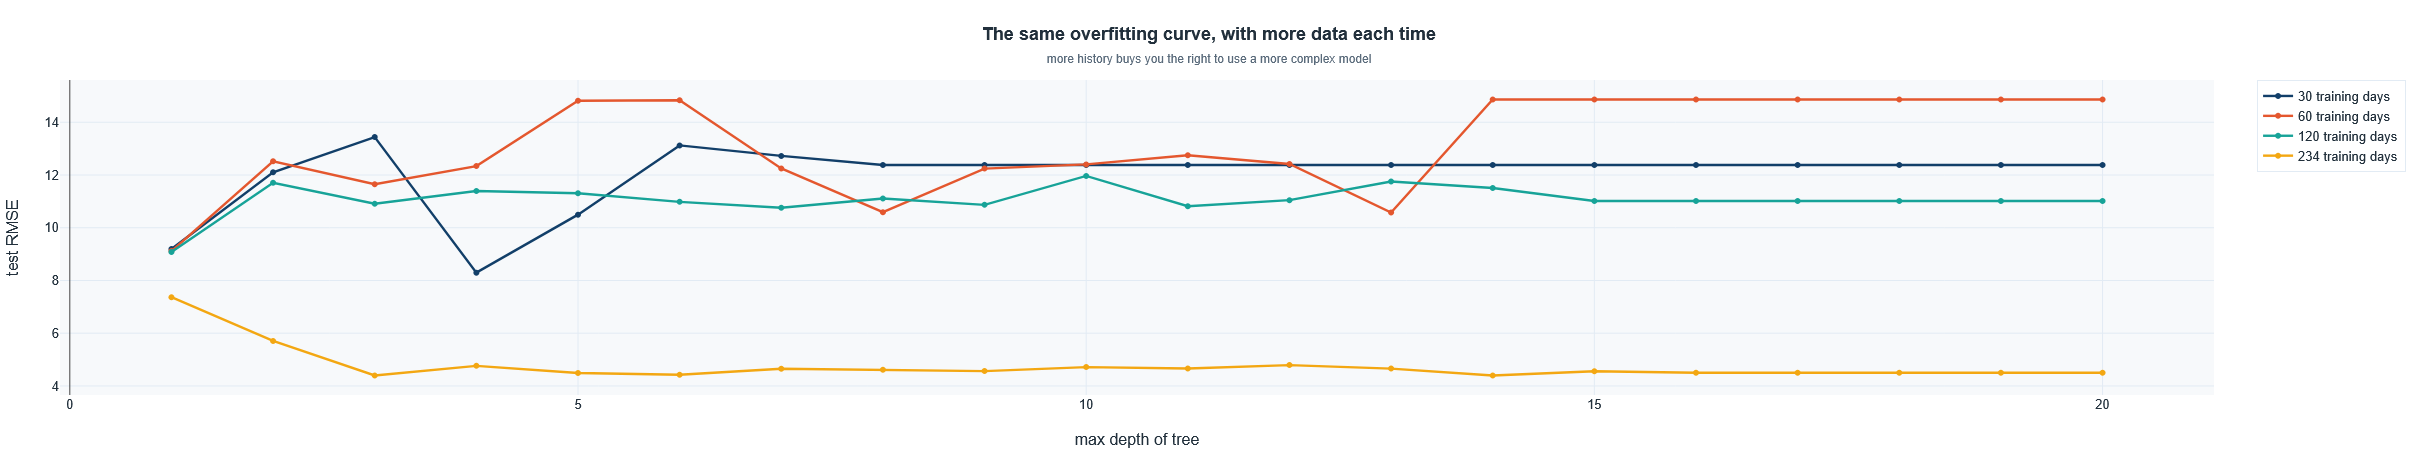

In [8]:
fig = go.Figure()
for j, n_train in enumerate([30, 60, 120, len(ytr)]):
    _, te_n, _ = depth_curves(n_train)
    fig.add_trace(go.Scatter(x=depths, y=te_n, mode="lines+markers",
                             name=f"{n_train} training days",
                             line=dict(color=COL[j], width=2.4)))
fig.update_layout(title="<b>The same overfitting curve, with more data each time</b><br>"
                        "<span style='font-size:12px;color:#5A6B7B'>more history buys you the "
                        "right to use a more complex model</span>",
                  xaxis_title="max depth of tree", yaxis_title="test RMSE", height=450)
fig.show()

## Part 6 — Some error is your fault; some was never yours

Two very different reasons a forecast can be wrong:

- the model is poor, or looking at the wrong things — **your problem, and fixable**
- the future genuinely has not been decided yet — **nobody's problem, and permanent**

Because we built this series, we can separate them. Below we rebuild it at different noise
levels and refit the same model each time.

The gap between the two lines is your **model's shortfall** — what better modelling could still
win. The height of the lower line is the **floor** — what the universe keeps. As noise rises the
model looks worse and worse, but it is not getting any dumber. It is being asked a harder
question.

> On real data you never see the lower line. This is the single most useful thing simulation
> buys you, and the reason Lecture 2c is built entirely on simulated processes.

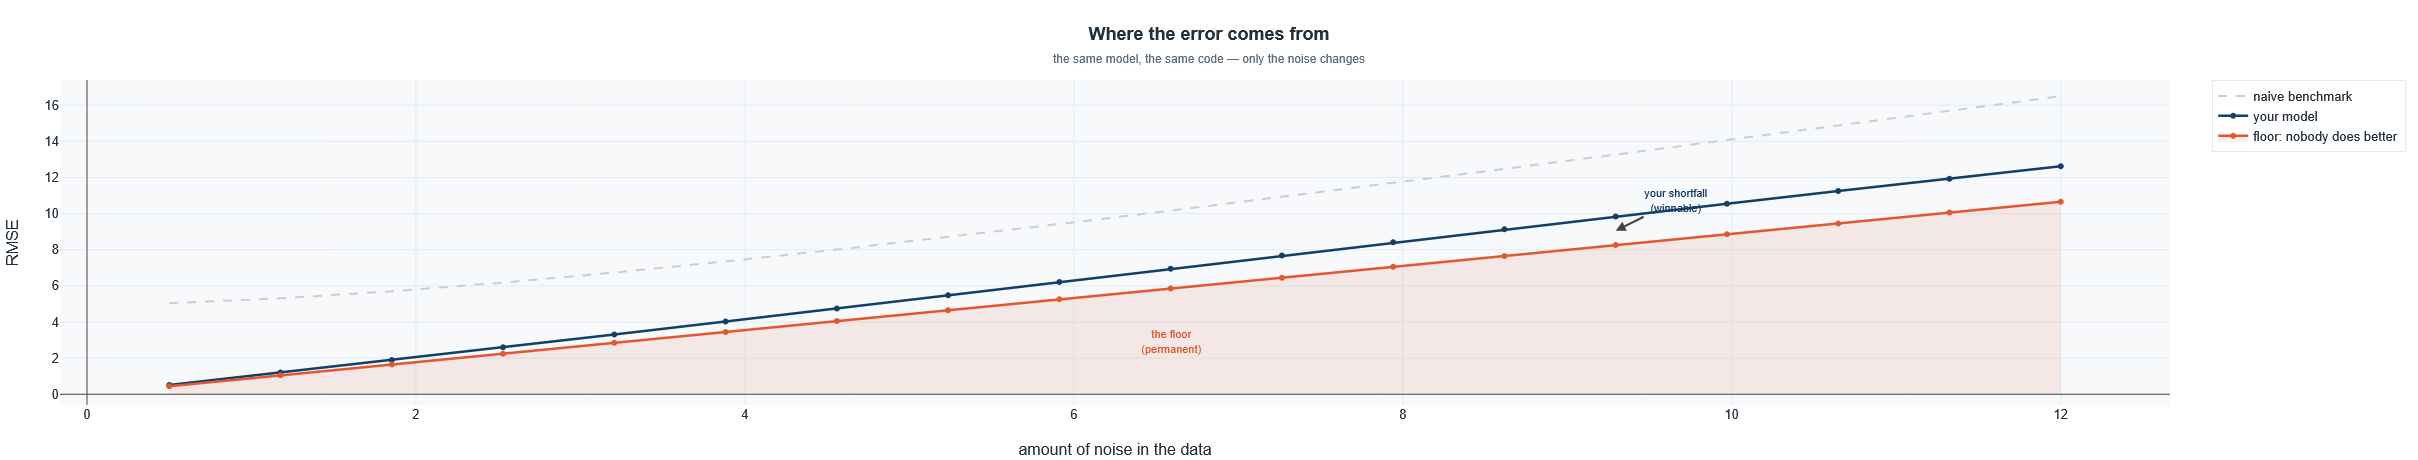

In [9]:
levels = np.linspace(0.5, 12, 18)
model_err, floor_err, naive_err = [], [], []
for lv in levels:
    d = signal + np.random.default_rng(SEED).normal(0, lv, n)
    Xa, ya = make_table(d)
    c = int(0.8 * len(ya))
    m = LinearRegression().fit(Xa[:c], ya[:c])
    model_err.append(rmse(m.predict(Xa[c:]), ya[c:]))
    floor_err.append(rmse(signal[W:][c:], ya[c:]))
    naive_err.append(rmse(Xa[c:, -1], ya[c:]))

fig = go.Figure()
fig.add_trace(go.Scatter(x=levels, y=naive_err, mode="lines", name="naive benchmark",
                         line=dict(color="#C6CFD8", width=2, dash="dash")))
fig.add_trace(go.Scatter(x=levels, y=model_err, mode="lines+markers", name="your model",
                         line=dict(color=COL[0], width=2.5)))
fig.add_trace(go.Scatter(x=levels, y=floor_err, mode="lines+markers",
                         name="floor: nobody does better",
                         line=dict(color=COL[1], width=2.5), fill="tozeroy",
                         fillcolor="rgba(228,87,46,0.10)"))
fig.add_annotation(x=levels[-5], y=(model_err[-5] + floor_err[-5]) / 2,
                   text="your shortfall<br>(winnable)", showarrow=True, arrowhead=2, ax=60, ay=-30,
                   font=dict(size=11, color=COL[0]))
fig.add_annotation(x=levels[-9], y=floor_err[-9] / 2, text="the floor<br>(permanent)",
                   showarrow=False, font=dict(size=11, color=COL[1]))
fig.update_layout(title="<b>Where the error comes from</b><br><span style='font-size:12px;"
                        "color:#5A6B7B'>the same model, the same code — only the noise changes</span>",
                  xaxis_title="amount of noise in the data", yaxis_title="RMSE", height=460)
fig.show()

## Part 7 — Why shuffling ruins everything

Every introductory ML tutorial contains this line:

```python
train_test_split(X, y, test_size=0.2, shuffle=True)
```

On a time series it is a catastrophe, and the catastrophe is silent — your score *improves*.

Here is the mechanism. Consecutive windows overlap heavily: the window for day 100 and the
window for day 101 share six of their seven values. Shuffle before splitting and day 100 lands
in training while day 101 lands in testing. A model that can memorise now has the answer sitting
in its training set. It is not forecasting; it is looking up a near-identical row.

The chart shows **two** models scored both ways, and the contrast between them is the real
lesson.

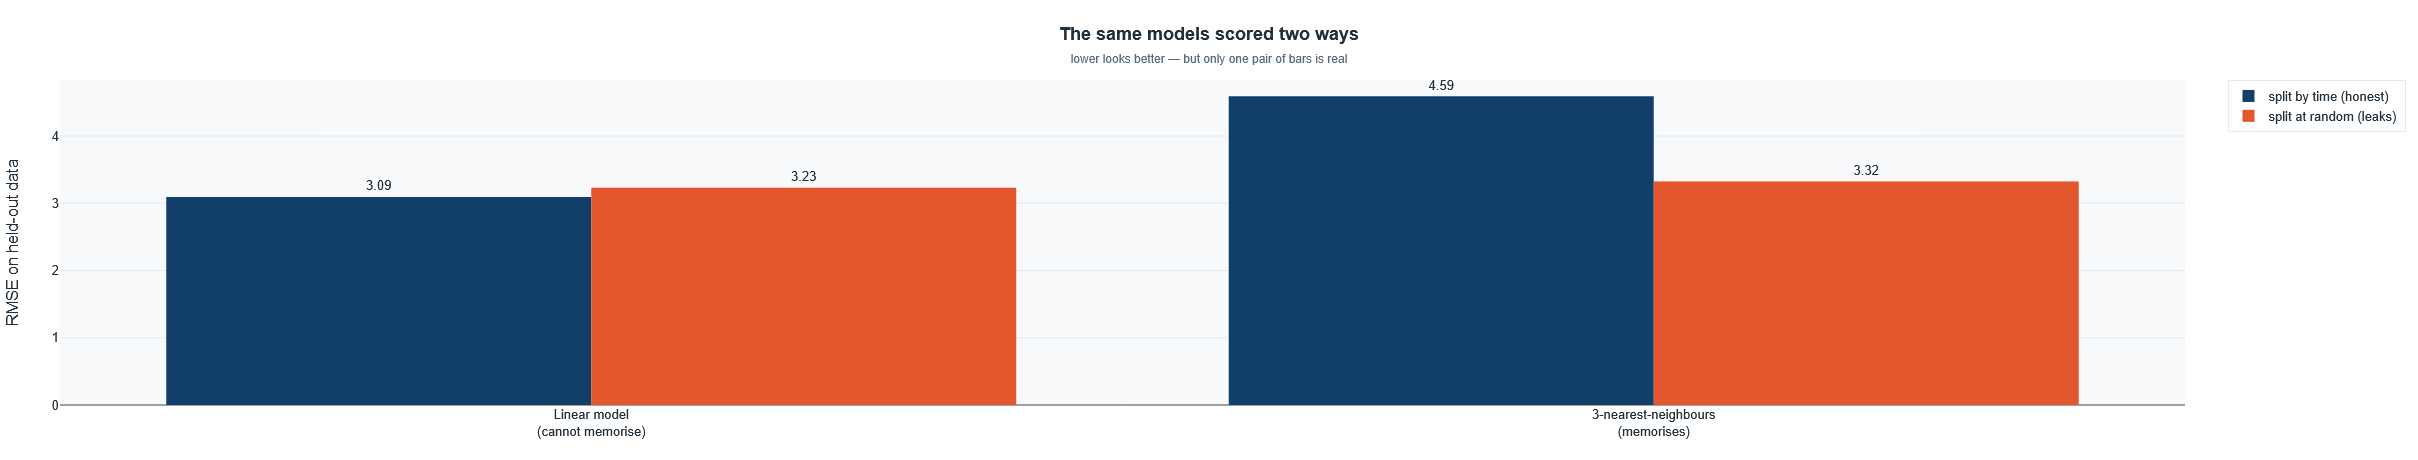

Linear model : time split  3.09  vs shuffled  3.23  ->  -4.5%
3-NN         : time split  4.59  vs shuffled  3.32  -> +27.6%


In [10]:
def score_both_ways(make_model):
    """Same model, same data, two different places to draw the line."""
    m1 = make_model().fit(Xtr, ytr)                       # honest: split by time
    e_time = rmse(m1.predict(Xte), yte)
    idx = np.random.default_rng(0).permutation(len(y))    # tempting: split at random
    tr_i, te_i = idx[:cut], idx[cut:]
    m2 = make_model().fit(X[tr_i], y[tr_i])
    return e_time, rmse(m2.predict(X[te_i]), y[te_i])

lin_time, lin_shuf = score_both_ways(lambda: LinearRegression())
knn_time, knn_shuf = score_both_ways(lambda: KNeighborsRegressor(n_neighbors=3))

fig = go.Figure()
fig.add_trace(go.Bar(x=["Linear model<br>(cannot memorise)", "3-nearest-neighbours<br>(memorises)"],
                     y=[lin_time, knn_time], name="split by time (honest)",
                     marker_color=COL[0], text=[f"{lin_time:.2f}", f"{knn_time:.2f}"],
                     textposition="outside"))
fig.add_trace(go.Bar(x=["Linear model<br>(cannot memorise)", "3-nearest-neighbours<br>(memorises)"],
                     y=[lin_shuf, knn_shuf], name="split at random (leaks)",
                     marker_color=COL[1], text=[f"{lin_shuf:.2f}", f"{knn_shuf:.2f}"],
                     textposition="outside"))
fig.update_layout(title="<b>The same models scored two ways</b><br><span style='font-size:12px;"
                        "color:#5A6B7B'>lower looks better — but only one pair of bars is real</span>",
                  barmode="group", yaxis_title="RMSE on held-out data", height=460)
fig.show()

print(f"Linear model : time split {lin_time:5.2f}  vs shuffled {lin_shuf:5.2f}  "
      f"-> {100*(lin_time-lin_shuf)/lin_time:+5.1f}%")
print(f"3-NN         : time split {knn_time:5.2f}  vs shuffled {knn_shuf:5.2f}  "
      f"-> {100*(knn_time-knn_shuf)/knn_time:+5.1f}%")

Two things fall out of that chart.

**The leak is large for the model that can memorise.** Shuffling made 3-NN look roughly a
quarter better than it truly is, because for most test windows the answer was three rows away
in the training set. Nothing about the model changed — only where the line was drawn.

**The linear model barely moved.** With seven weights it has nowhere to store a lookup table,
so it cannot exploit the leak even when handed one. This is the trap: validate your pipeline
with a simple model, see no problem, then deploy a tree ensemble or a neural network into the
same leaky protocol and never find out.

The models people actually deploy are the memorising kind. **Draw the split by time.**

## Part 8 — How far ahead can you see?

So far we have forecast one day ahead. Push the horizon out and watch what happens.

The weekly cycle is genuinely periodic, so the model holds up for a surprisingly long way. But
the *level* of the series drifts unpredictably, and that uncertainty compounds with every step.
Eventually the model does no better than the benchmark, and the honest answer becomes "I don't
know."

Knowing where your horizon ends is not a weakness in a forecaster. It is the job.

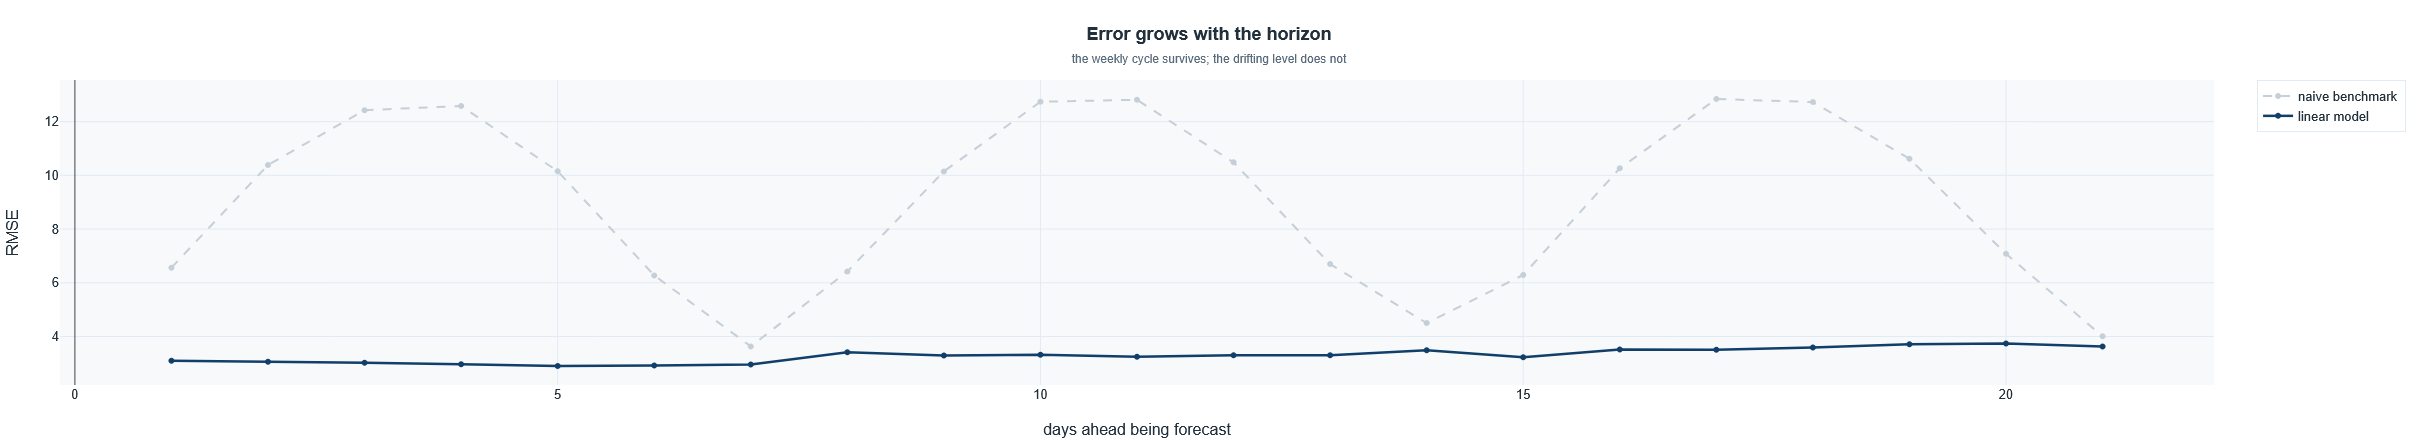

In [11]:
horizons = list(range(1, 22))
h_model, h_naive = [], []
for h in horizons:
    Xh, yh = make_table(demand, W, horizon=h)
    c = int(0.8 * len(yh))
    m = LinearRegression().fit(Xh[:c], yh[:c])
    h_model.append(rmse(m.predict(Xh[c:]), yh[c:]))
    h_naive.append(rmse(Xh[c:, -1], yh[c:]))

fig = go.Figure()
fig.add_trace(go.Scatter(x=horizons, y=h_naive, mode="lines+markers", name="naive benchmark",
                         line=dict(color="#C6CFD8", width=2, dash="dash")))
fig.add_trace(go.Scatter(x=horizons, y=h_model, mode="lines+markers", name="linear model",
                         line=dict(color=COL[0], width=2.5)))
cross = next((h for h, a, b in zip(horizons, h_model, h_naive) if a >= b), None)
if cross:
    fig.add_vline(x=cross, line_dash="dot", line_color=COL[1],
                  annotation_text=f"beyond day {cross}, no better than naive",
                  annotation_position="top left")
fig.update_layout(title="<b>Error grows with the horizon</b><br><span style='font-size:12px;"
                        "color:#5A6B7B'>the weekly cycle survives; the drifting level does not</span>",
                  xaxis_title="days ahead being forecast", yaxis_title="RMSE", height=440)
fig.show()

## Part 9 — A reality check from finance

Everything so far worked because the series *had* structure to find. Now run the identical
pipeline on daily returns of a share price.

Nothing changes but the data. The window, the split, the model, the benchmark are all the same.

The result is the flat, useless line you are about to see — and that is not a bug, or a badly
tuned model, or a case for a bigger network. It is the finding. Financial returns are close to
unforecastable from their own past, which is why so much of this subject is about **measuring
honestly** rather than predicting harder.

If a backtest ever shows you a chart on returns that looks like Part 4 did, your first
assumption should be that something has leaked.

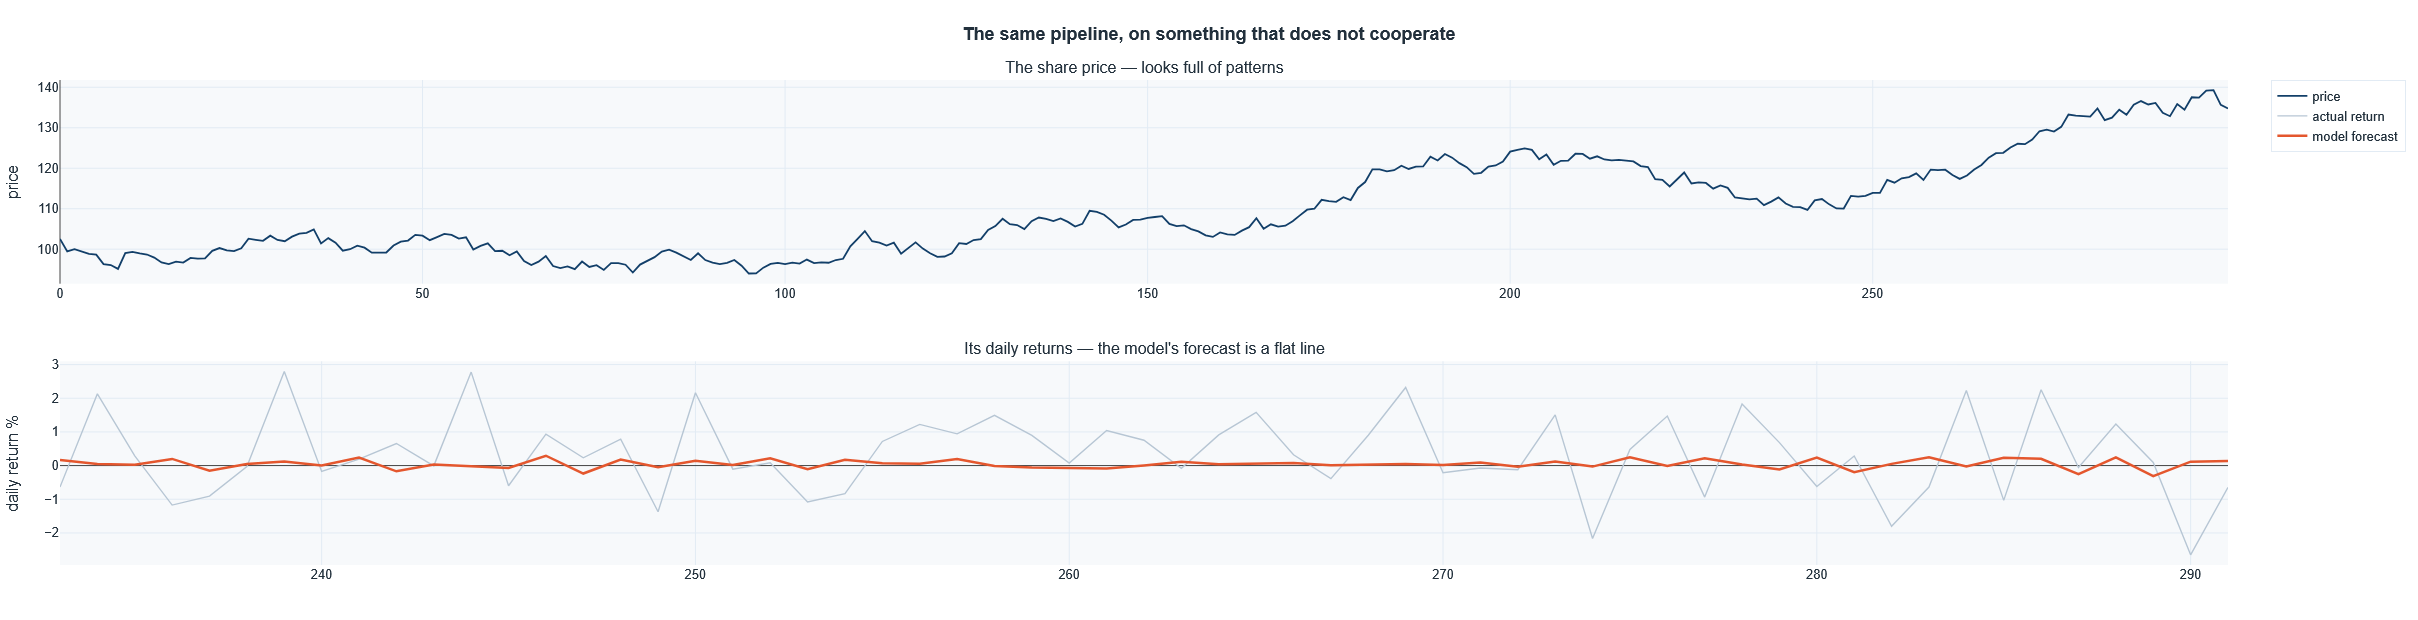

model RMSE             1.225
'same as yesterday'    1.814
'just use the average' 1.215   <- the sensible benchmark here

Improvement on the sensible benchmark: -0.8%
Roughly zero. There was nothing there to find.


In [12]:
price = 100 * np.exp(np.cumsum(np.random.default_rng(3).normal(0.0004, 0.012, n)))
returns = np.diff(np.log(price)) * 100

Xr, yr = make_table(returns)
c = int(0.8 * len(yr))
mr = LinearRegression().fit(Xr[:c], yr[:c])
pr = mr.predict(Xr[c:])
r_model, r_naive = rmse(pr, yr[c:]), rmse(Xr[c:, -1], yr[c:])
r_mean = rmse(np.full(len(yr) - c, yr[:c].mean()), yr[c:])

fig = make_subplots(rows=2, cols=1, shared_xaxes=False, vertical_spacing=0.16,
                    subplot_titles=("The share price — looks full of patterns",
                                    "Its daily returns — the model's forecast is a flat line"))
fig.add_trace(go.Scatter(y=price, mode="lines", line=dict(color=COL[0], width=1.8),
                         name="price"), row=1, col=1)
fig.add_trace(go.Scatter(x=np.arange(len(yr))[c:], y=yr[c:], mode="lines", name="actual return",
                         line=dict(color="#B7C6D4", width=1.4)), row=2, col=1)
fig.add_trace(go.Scatter(x=np.arange(len(yr))[c:], y=pr, mode="lines", name="model forecast",
                         line=dict(color=COL[1], width=2.5)), row=2, col=1)
fig.update_layout(height=620, title="<b>The same pipeline, on something that does not cooperate</b>")
fig.update_yaxes(title_text="price", row=1, col=1); fig.update_yaxes(title_text="daily return %", row=2, col=1)
fig.show()

print(f"model RMSE            {r_model:6.3f}")
print(f"'same as yesterday'   {r_naive:6.3f}")
print(f"'just use the average'{r_mean:6.3f}   <- the sensible benchmark here")
print(f"\nImprovement on the sensible benchmark: {100*(1-r_model/r_mean):+.1f}%")
print("Roughly zero. There was nothing there to find.")

## Part 10 — Your turn

One function, four things to change. Every run takes under a second.

```python
experiment(window=7, model="linear", noise=3, horizon=1)
```

- `window` — how many past days the model sees (try 2, then 7, then 30)
- `model` — `"naive"`, `"linear"`, `"tree"`, `"knn"`
- `noise` — how unpredictable the world is (try 1, then 10)
- `horizon` — how many days ahead (try 1, then 14)

**Three worth doing before the exercises:**

1. `window=2` then `window=7` then `window=14`. Why does 7 matter so much, and why does 14 add so little?
2. `noise=1` then `noise=10`, with everything else fixed. The model is identical. What moved?
3. `model="knn"` with `window=30`. Compare against `model="linear"` and think about which is
   actually looking at more information.

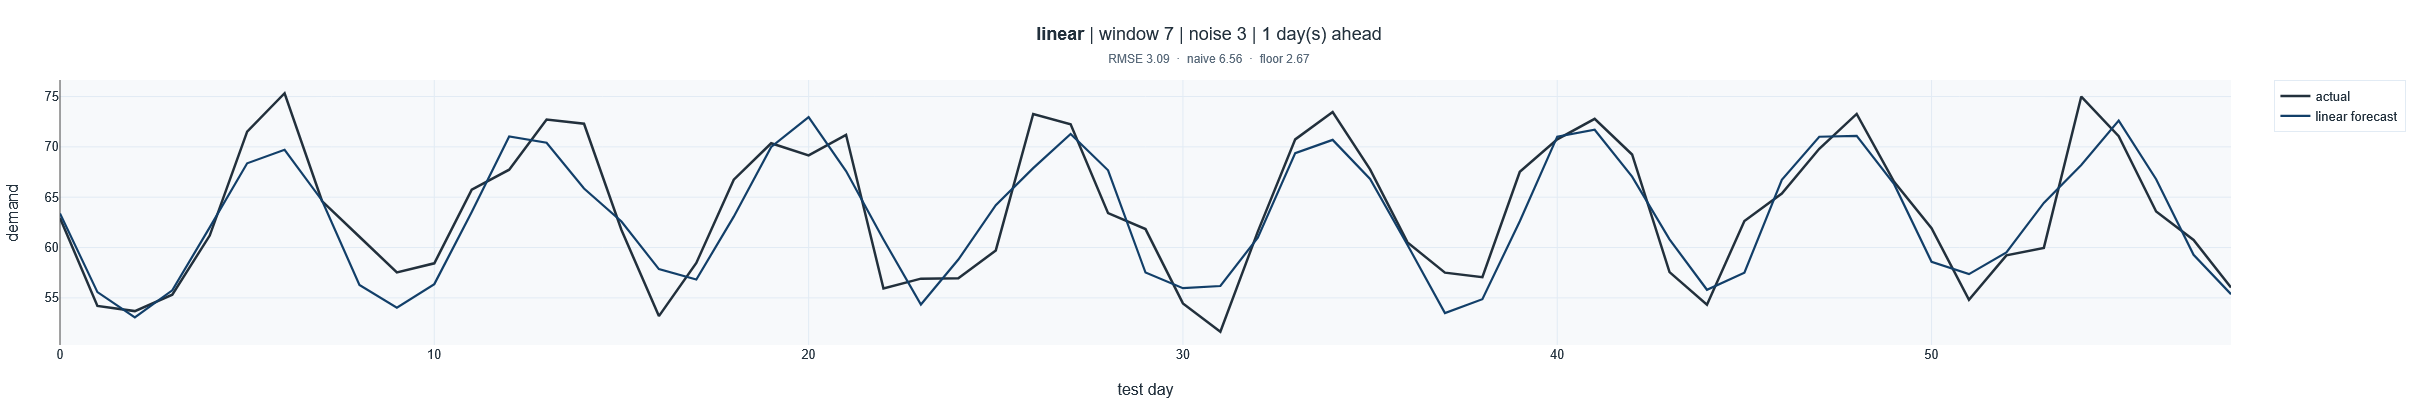

Beat the naive benchmark by  52.9%
Captured  89.0% of the improvement that was available


In [13]:
def experiment(window=7, model="linear", noise=3, horizon=1, seed=SEED, show=True):
    """Run one forecasting experiment end to end. Returns a small summary."""
    d = signal + np.random.default_rng(seed).normal(0, noise, n)
    Xa, ya = make_table(d, window, horizon)
    c = int(0.8 * len(ya))
    Xa_tr, Xa_te, ya_tr, ya_te = Xa[:c], Xa[c:], ya[:c], ya[c:]

    est = {"naive":  None,
           "linear": LinearRegression(),
           "tree":   DecisionTreeRegressor(max_depth=5, random_state=0),
           "knn":    KNeighborsRegressor(n_neighbors=5)}[model]
    p = Xa_te[:, -1] if est is None else est.fit(Xa_tr, ya_tr).predict(Xa_te)

    e_model = rmse(p, ya_te)
    e_naive = rmse(Xa_te[:, -1], ya_te)
    e_floor = rmse(signal[window + horizon - 1:][c:], ya_te)

    if show:
        fig = go.Figure()
        fig.add_trace(go.Scatter(y=ya_te, mode="lines", name="actual",
                                 line=dict(color="#22303C", width=2.5)))
        fig.add_trace(go.Scatter(y=p, mode="lines", name=f"{model} forecast",
                                 line=dict(color=COL[0], width=2.2)))
        fig.update_layout(
            title=f"<b>{model}</b> | window {window} | noise {noise} | {horizon} day(s) ahead"
                  f"<br><span style='font-size:12px;color:#5A6B7B'>RMSE {e_model:.2f} &nbsp;·&nbsp; "
                  f"naive {e_naive:.2f} &nbsp;·&nbsp; floor {e_floor:.2f}</span>",
            xaxis_title="test day", yaxis_title="demand", height=400)
        fig.show()
        beat = 100 * (1 - e_model / e_naive)
        avail = e_naive - e_floor
        print(f"Beat the naive benchmark by {beat:5.1f}%")
        if avail > 1e-9:
            print(f"Captured {100*(e_naive-e_model)/avail:5.1f}% of the improvement that was available")
    return dict(model=model, window=window, noise=noise, horizon=horizon,
                rmse=e_model, naive=e_naive, floor=e_floor)

_ = experiment(window=7, model="linear", noise=3, horizon=1)

In [14]:
# A quick sweep. Edit the list and re-run — the whole cell takes about a second.
rows = [experiment(window=w, model="linear", show=False) for w in [2, 3, 5, 7, 10, 14, 21, 30]]
tbl = pd.DataFrame(rows)[["window", "rmse", "naive", "floor"]]
tbl["beats naive by"] = (100 * (1 - tbl["rmse"] / tbl["naive"])).round(1).astype(str) + "%"
display(tbl.round(2).style.hide(axis="index"))

window,rmse,naive,floor,beats naive by
2,6.230000,6.520000,2.650000,4.4%
3,6.820000,6.520000,2.650000,-4.6%
5,4.540000,6.560000,2.670000,30.9%
7,3.090000,6.560000,2.670000,52.9%
10,2.980000,6.520000,2.670000,54.3%
14,3.060000,6.520000,2.670000,53.2%
21,2.980000,6.530000,2.650000,54.4%
30,3.280000,6.600000,2.690000,50.3%


## Part 11 — Exercises

### Core

1. **Find the week.** Using the sweep in Part 10, identify the smallest window that captures most
   of the available improvement. Explain in one sentence why that number is what it is, and why
   going further adds so little.

2. **Make the tree behave.** In Part 5, read off the depth with the lowest test error. Then set
   `model="tree"` in `experiment()` and change `max_depth` in the function to 2, then to 5, then
   to 20. Report the three RMSEs and say which one you would have shipped.

3. **Two kinds of wrong.** Run `experiment(noise=1)` and `experiment(noise=10)`. The model is
   unchanged. Explain which of the two error sources in Part 6 moved, and how you would have
   known this without being told the answer.

4. **Break it on purpose.** Modify the Part 7 code so the shuffled split uses a window of 30
   instead of 7. Does the fictional improvement get bigger or smaller? Explain why overlap
   is the mechanism.

### Stretch

5. **A new pattern.** Replace the weekly cycle with a monthly one (period 30) and rerun the window
   sweep. Predict beforehand where the improvement will appear, then check whether you were right.

6. **An honest horizon.** Extend Part 8 to 60 days and add the floor as a third line. At what
   horizon does the *floor itself* reach the naive benchmark — and what does it mean when it does?

7. **Feature engineering.** Add the day of the week as an explicit extra input column. Does the
   linear model improve? Explain your result in terms of what Part 4 showed about the weights it
   had already learned.

8. **The real thing.** Swap the simulated demand for any real daily series you can obtain offline.
   You no longer have a floor, so you cannot say how much of the available improvement you
   captured. Write a short paragraph on what you can still legitimately claim.

## What to take away

1. **A series becomes a table.** Slide a window; the window is the input and the next value is
   the answer. Everything else in ML forecasting is a variation on this one move.

2. **A number alone means nothing.** An RMSE of 3.1 is neither good nor bad until you have a
   benchmark. Start with "same as yesterday" and make every model earn its place.

3. **Falling training error is not progress.** It fell all the way to depth 20 while the forecasts
   got worse. You need two curves before you can tell what is happening.

4. **Not all error is your fault.** Some was decided by the model; some was never available to
   anyone. Confusing the two leads people to tune forever against a wall.

5. **Time series break the standard recipe.** Shuffling before splitting improved the score by
   leaking the future into the past. The improvement was not real.

6. **Sometimes the honest answer is that there is no signal.** Part 9 is not a failed experiment.
   It is the normal condition of financial returns, and recognising it quickly is a professional
   skill.

---

**Next:** Lecture 2c takes these same five ideas and runs them through LSTMs, GRUs, convolutional
networks and echo state networks across eight processes of escalating difficulty. You will find
that the conclusions do not change much — which is rather the point.